In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [20]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = 'cpu'
device

'cpu'

In [21]:
class NCFDataset(Dataset):
    def __init__(self, user_ids, item_ids, ratings):
        self.user_ids = user_ids
        self.item_ids = item_ids
        self.ratings = ratings

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.user_ids[idx], self.item_ids[idx], self.ratings[idx]

In [22]:
# GMF Class (Generalized Matrix Factorization)
class GMF(nn.Module):
    def __init__(self, num_users, num_items, latent_dim):
        super(GMF, self).__init__()
        # Embedding layers for users and items
        self.user_embedding = nn.Embedding(num_users, latent_dim)
        self.item_embedding = nn.Embedding(num_items, latent_dim)

    def forward(self, user_ids, item_ids):
        user_emb = self.user_embedding(user_ids)  # Shape: [batch_size, latent_dim]
        item_emb = self.item_embedding(item_ids)  # Shape: [batch_size, latent_dim]
        
        # GMF: Element-wise product
        return user_emb * item_emb  # Shape: [batch_size, latent_dim]

In [23]:
# MLP Class (Multi-Layer Perceptron)
class MLP(nn.Module):
    def __init__(self, latent_dim, hidden_layers):
        super(MLP, self).__init__()
        input_dim = latent_dim * 2  # Concatenated user and item embeddings
        layers = []
        for units in hidden_layers:
            layers.append(nn.Linear(input_dim, units))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.2))
            input_dim = units
        self.mlp = nn.Sequential(*layers)

    def forward(self, user_ids, item_ids, user_embedding, item_embedding):
        # Concatenate user and item embeddings
        x = torch.cat([user_embedding, item_embedding], dim=-1)  # Shape: [batch_size, latent_dim * 2]
        return self.mlp(x)  # Shape: [batch_size, last_hidden_layer_size]

In [24]:
# NCF Class (Neural Collaborative Filtering) with GMF and MLP
class NCF(nn.Module):
    def __init__(self, num_users, num_items, latent_dim=16, hidden_layers=[64, 32, 16]):
        super(NCF, self).__init__()
        
        # GMF component
        self.gmf = GMF(num_users, num_items, latent_dim)
        
        # MLP component
        self.mlp = MLP(latent_dim, hidden_layers)
        
        # Output Layer (Fusion of GMF and MLP)
        fusion_dim = latent_dim + hidden_layers[-1]  # GMF (latent_dim) + MLP (last hidden layer)
        self.output_layer = nn.Linear(fusion_dim, 1)  # Single output value for regression
        
    def forward(self, user_ids, item_ids):
        # Get GMF output (element-wise product of embeddings)
        gmf_output = self.gmf(user_ids, item_ids)
        
        # Get MLP output (processed through hidden layers)
        user_emb = self.gmf.user_embedding(user_ids)
        item_emb = self.gmf.item_embedding(item_ids)
        mlp_output = self.mlp(user_ids, item_ids, user_emb, item_emb)
        
        # Combine GMF and MLP outputs
        combined = torch.cat([gmf_output, mlp_output], dim=-1)  # Shape: [batch_size, fusion_dim]
        
        # Final prediction (single value for regression)
        output = self.output_layer(combined)  # Shape: [batch_size, 1]
        return output

In [25]:
attraction_df = pd.read_csv('../Data/FinalDataset/attractions_final.csv')
ratings_df = pd.read_csv('../Data/FinalDataset/ratings.csv')
ratings_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3075 entries, 0 to 3074
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   user_id   3075 non-null   int64
 1   place_id  3075 non-null   int64
 2   rating    3075 non-null   int64
dtypes: int64(3)
memory usage: 72.2 KB


In [26]:
ratings_df['place_id'] = ratings_df['place_id'].fillna(-1)
ratings_df = ratings_df.drop_duplicates(subset=['user_id', 'place_id'])



In [27]:
# Initialize label encoders for user_id and place_id
user_encoder = LabelEncoder()
place_encoder = LabelEncoder()

# Fit and transform the user_id and place_id to continuous integers starting from 0 
ratings_df['user_id'] = user_encoder.fit_transform(ratings_df['user_id'])
ratings_df['place_id'] = place_encoder.fit_transform(ratings_df['place_id'])

# Now the user_id and place_id are mapped to indices starting from 0
num_users = len(user_encoder.classes_)  # Number of unique users
num_items = len(place_encoder.classes_)  # Number of unique places
print(num_users, num_items)

2641 476


In [28]:
train_df, test_df = train_test_split(
    ratings_df,
    test_size=0.2,
    random_state=42,
)

In [29]:
# Convert split DataFrames to tensors
train_user_ids = torch.tensor(train_df['user_id'].values, dtype=torch.long)
train_item_ids = torch.tensor(train_df['place_id'].values, dtype=torch.long)
train_ratings = torch.tensor(train_df['rating'].values, dtype=torch.float32)

test_user_ids = torch.tensor(test_df['user_id'].values, dtype=torch.long)
test_item_ids = torch.tensor(test_df['place_id'].values, dtype=torch.long)
test_ratings = torch.tensor(test_df['rating'].values, dtype=torch.float32)

In [30]:
# After your split, add these checks:
print("\nTrain set statistics:")
print(train_ratings.float().mean())
print(train_ratings.float().std())
print(train_df['rating'].value_counts())

print("\nTest set statistics:")
print(test_ratings.float().mean())
print(test_ratings.float().std())
print(test_df['rating'].value_counts())


Train set statistics:
tensor(4.4461)
tensor(0.9746)
rating
5    1593
4     492
3     176
1      74
2      50
0       7
Name: count, dtype: int64

Test set statistics:
tensor(4.4599)
tensor(0.9101)
rating
5    388
4    139
3     46
1     15
2      9
0      1
Name: count, dtype: int64


In [31]:
print("\nUnique users in train:", len(train_df['user_id'].unique()))
print("Unique users in test:", len(test_df['user_id'].unique()))
print("Unique items in train:", len(train_df['place_id'].unique()))
print("Unique items in test:", len(test_df['place_id'].unique()))

# Check overlap
train_users_set = set(train_df['user_id'].unique())
test_users_set = set(test_df['user_id'].unique())
print("\nUsers only in test:", len(test_users_set - train_users_set))

train_items_set = set(train_df['place_id'].unique())
test_items_set = set(test_df['place_id'].unique())
print("Items only in test:", len(test_items_set - train_items_set))


Unique users in train: 2150
Unique users in test: 576
Unique items in train: 460
Unique items in test: 333

Users only in test: 491
Items only in test: 16


In [32]:
# Create train and test datasets
train_dataset = NCFDataset(train_user_ids, train_item_ids, train_ratings)
test_dataset = NCFDataset(test_user_ids, test_item_ids, test_ratings)

In [33]:
# Create DataLoader for training and testing
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [34]:
# Initialize the model, loss function, and optimizer
model = NCF(num_users, num_items, latent_dim=16, hidden_layers=[64, 32, 16]).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [35]:
# Lists to store training and test loss for each epoch
train_losses = []
test_losses = []

# Training loop
num_epochs = 10
for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    running_loss = 0.0
    
    for user_ids, item_ids, ratings in train_loader:
        user_ids, item_ids, ratings = user_ids.to(device), item_ids.to(device), ratings.to(device)
        
        optimizer.zero_grad()  # Zero the gradients
        predictions = model(user_ids, item_ids)
        
        loss = criterion(predictions.squeeze(), ratings)  # Calculate the loss
        loss.backward()  # Backpropagate the error
        optimizer.step()  # Update the weights
        
        running_loss += loss.item()
    
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)  # Store the training loss
    
    # Evaluation phase
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():  # No gradient computation needed for evaluation
        test_loss = 0.0
        for user_ids, item_ids, ratings in test_loader:
            user_ids, item_ids, ratings = user_ids.to(device), item_ids.to(device), ratings.to(device)
            
            predictions = model(user_ids, item_ids)
            loss = criterion(predictions.squeeze(), ratings)  # Calculate the loss for the test set
            test_loss += loss.item()
        
        avg_test_loss = test_loss / len(test_loader)
        test_losses.append(avg_test_loss)  # Store the test loss
    
    # Print the loss for each epoch
    print(f"Epoch {epoch+1}/{num_epochs}, Training Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}")


Epoch 1/10, Training Loss: 19.1031, Test Loss: 14.9028
Epoch 2/10, Training Loss: 7.8012, Test Loss: 1.5684
Epoch 3/10, Training Loss: 3.0694, Test Loss: 1.4491
Epoch 4/10, Training Loss: 2.6066, Test Loss: 1.4385
Epoch 5/10, Training Loss: 2.5618, Test Loss: 1.3405
Epoch 6/10, Training Loss: 2.3344, Test Loss: 1.3339
Epoch 7/10, Training Loss: 2.3377, Test Loss: 1.2558
Epoch 8/10, Training Loss: 2.1998, Test Loss: 1.2071
Epoch 9/10, Training Loss: 2.1340, Test Loss: 1.1526
Epoch 10/10, Training Loss: 1.9654, Test Loss: 1.1760


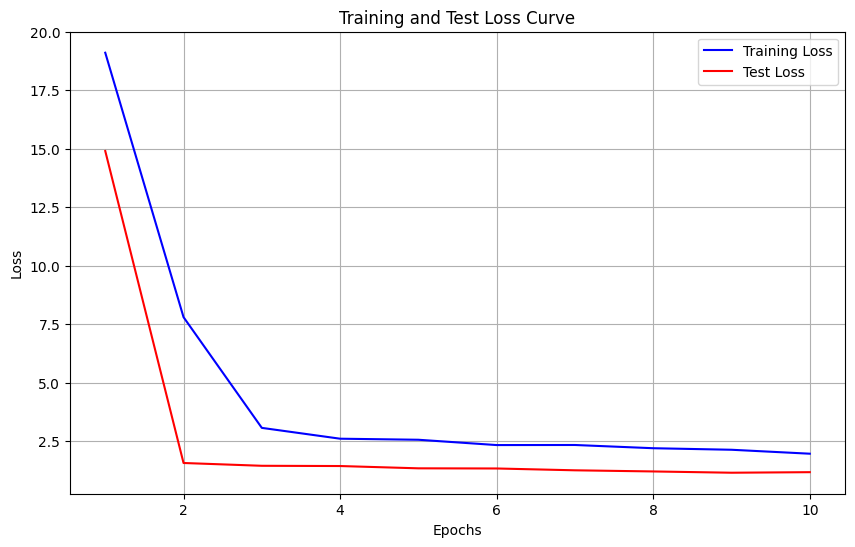

In [36]:
# Plotting the training and test loss curves
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs+1), train_losses, label="Training Loss", color="blue")
plt.plot(range(1, num_epochs+1), test_losses, label="Test Loss", color="red")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Test Loss Curve')
plt.legend()
plt.grid(True)
plt.show()